##1. Data Ingestion and Preparation

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

df = pd.read_csv('Sample - Superstore.csv', encoding='latin1')

df['Order Date'] = pd.to_datetime(df['Order Date'])

df['YearMonth'] = df['Order Date'].dt.to_period('M')

df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit,YearMonth
0,1,CA-2016-152156,2016-11-08,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136,2016-11
1,2,CA-2016-152156,2016-11-08,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820,2016-11
2,3,CA-2016-138688,2016-06-12,6/16/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714,2016-06
3,4,US-2015-108966,2015-10-11,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310,2015-10
4,5,US-2015-108966,2015-10-11,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164,2015-10


##2. Visualization One

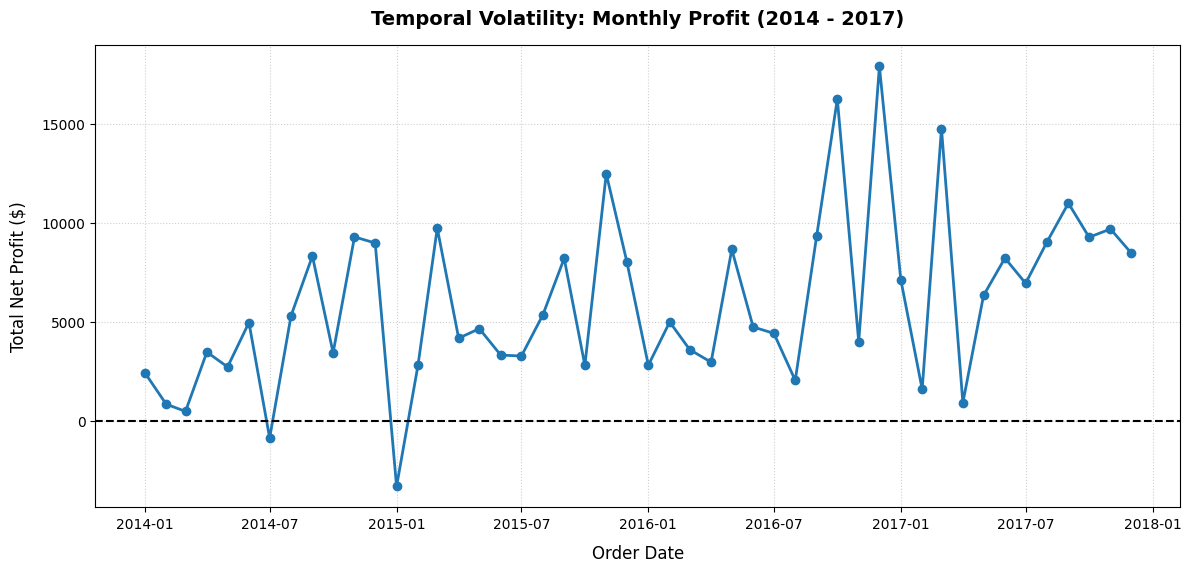

In [6]:
monthly_profit = df.groupby('YearMonth')['Profit'].sum().reset_index()

monthly_profit['YearMonth'] = monthly_profit['YearMonth'].dt.to_timestamp()

fig, ax = plt.subplots(figsize=(14, 6))

ax.plot(monthly_profit['YearMonth'], monthly_profit['Profit'], color='tab:blue', linewidth=2, marker='o')

ax.set_title('Temporal Volatility: Monthly Profit (2014 - 2017)', fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('Order Date', fontsize=12, labelpad=10)
ax.set_ylabel('Total Net Profit ($)', fontsize=12, labelpad=10)

ax.axhline(0, color='black', linewidth=1.5, linestyle='--')

ax.grid(True, linestyle=':', alpha=0.6)

fig.savefig('temporal_volatility.png', dpi=300, bbox_inches='tight')

plt.show()

##3. Visualization Two

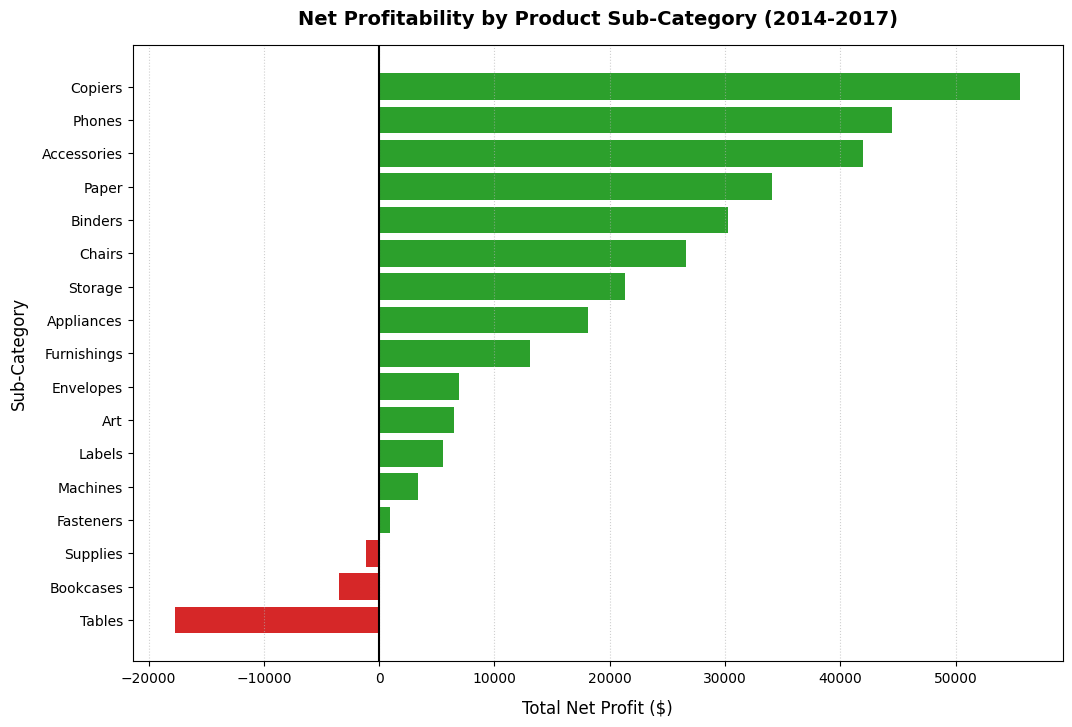

In [7]:
subcat_profit = df.groupby('Sub-Category')['Profit'].sum().sort_values()

bar_colors = ['tab:red' if val < 0 else 'tab:green' for val in subcat_profit]

fig, ax = plt.subplots(figsize=(12, 8))

bars = ax.barh(subcat_profit.index, subcat_profit.values, color=bar_colors)

ax.set_title('Net Profitability by Product Sub-Category (2014-2017)', fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('Total Net Profit ($)', fontsize=12, labelpad=10)
ax.set_ylabel('Sub-Category', fontsize=12, labelpad=10)

ax.axvline(0, color='black', linewidth=1.5, linestyle='-')

ax.grid(axis='x', linestyle=':', alpha=0.6)

fig.savefig('categorical_profitability.png', dpi=300, bbox_inches='tight')

plt.show()

##4. Visualization Three

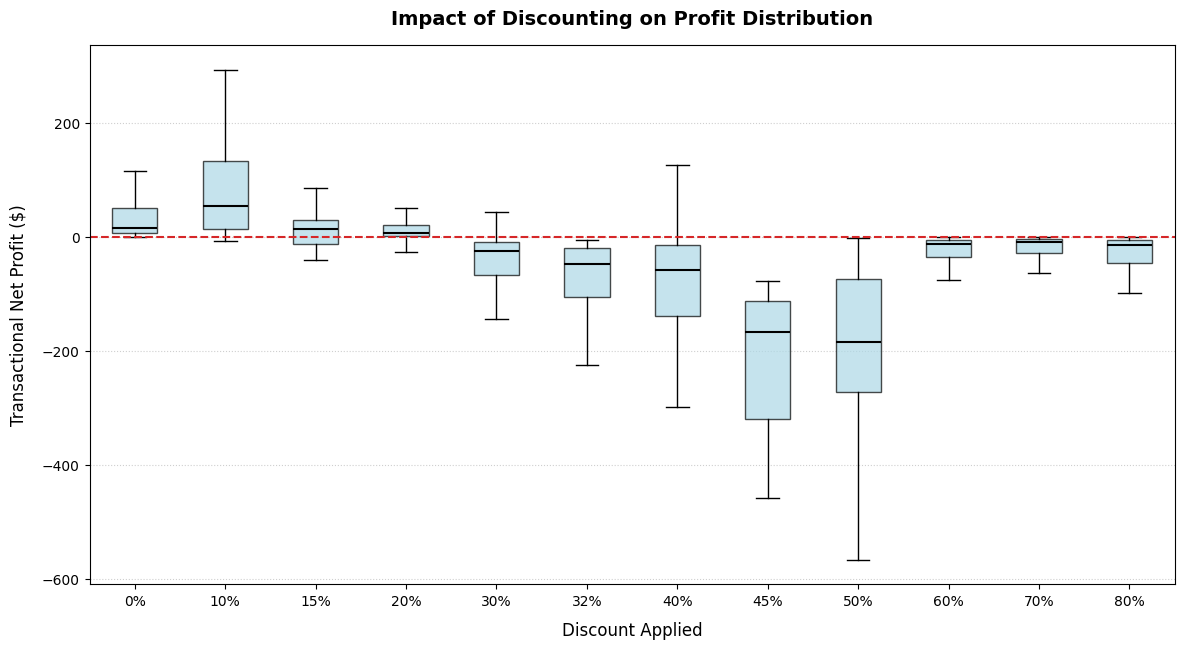

In [8]:
discounts = sorted(df['Discount'].unique())

profit_by_discount = [df[df['Discount'] == d]['Profit'] for d in discounts]

fig, ax = plt.subplots(figsize=(14, 7))

bplot = ax.boxplot(profit_by_discount,
                   patch_artist=True,
                   showfliers=False,
                   medianprops=dict(color='black', linewidth=1.5))

for patch in bplot['boxes']:
    patch.set_facecolor('lightblue')
    patch.set_alpha(0.7)

x_labels = [f"{d*100:.0f}%" for d in discounts]
ax.set_xticklabels(x_labels)

ax.set_title('Impact of Discounting on Profit Distribution', fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('Discount Applied', fontsize=12, labelpad=10)
ax.set_ylabel('Transactional Net Profit ($)', fontsize=12, labelpad=10)

ax.axhline(0, color='tab:red', linewidth=1.5, linestyle='--')

ax.grid(axis='y', linestyle=':', alpha=0.6)

fig.savefig('discount_correlation_boxplots.png', dpi=300, bbox_inches='tight')

plt.show()